# 🟠 TP4 | Projeto de Bloco: Inteligência Artificial e Machine Learning

Objetivos:

* Investigar a eficácia do uso de clusters gerados pelo algoritmo K-Médias como features adicionais em tarefas de classificação.
* Comparar o desempenho de modelos SVM treinados com e sem o uso dessas features derivadas de clusterização em conjuntos de dados variados.
* Avaliar a influência do número de clusters e da seleção de parâmetros no desempenho do modelo SVM final.
* Desenvolver diretrizes para a aplicação efetiva de técnicas de clusterização em engenharia de features para aprendizado supervisionado.

Base de dados: [Fake.BR - Corpus](https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/refs/heads/master/preprocessed/pre-processed.csv)

## ⤵️ Imports

In [52]:
from sklearn.metrics import silhouette_score, silhouette_samples, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import pandas as pd
import numpy as np
import nltk

In [53]:
raw_data = pd.read_csv('https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/refs/heads/master/preprocessed/pre-processed.csv')

In [54]:
raw_data.head()

,index,label,preprocessed_news
0,0,fake,katia abreu diz vai colocar expulsao moldura n...
1,1,fake,ray peita bolsonaro conservador fake entrevist...
2,2,fake,reinaldo azevedo desmascarado policia federal ...
3,3,fake,relatorio assustador bndes mostra dinheiro pub...
4,4,fake,radialista americano fala sobre pt vendem ilus...


In [55]:
nltk.download('stopwords')
stopwords_pt = stopwords.words('portuguese')

raw_data['label'] = raw_data['label'].map({
  'fake': 0,
  'true': 1
})

y = raw_data['label']
X = (
    raw_data['preprocessed_news']
    .fillna('')
    .astype(str)
    .str.lower()
    .str.replace(r'\d+', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(
    max_df = 0.90,
    min_df=0.1,
    max_features=600,
    stop_words=stopwords_pt
)

X_train_tfidf = tfidf.fit_transform(X_train)
feature_names = tfidf.get_feature_names_out()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [56]:
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 344689 stored elements and shape (5760, 332)>

In [57]:
pca1 = PCA()
X_pca1 = pca1.fit(X_train_tfidf.toarray())

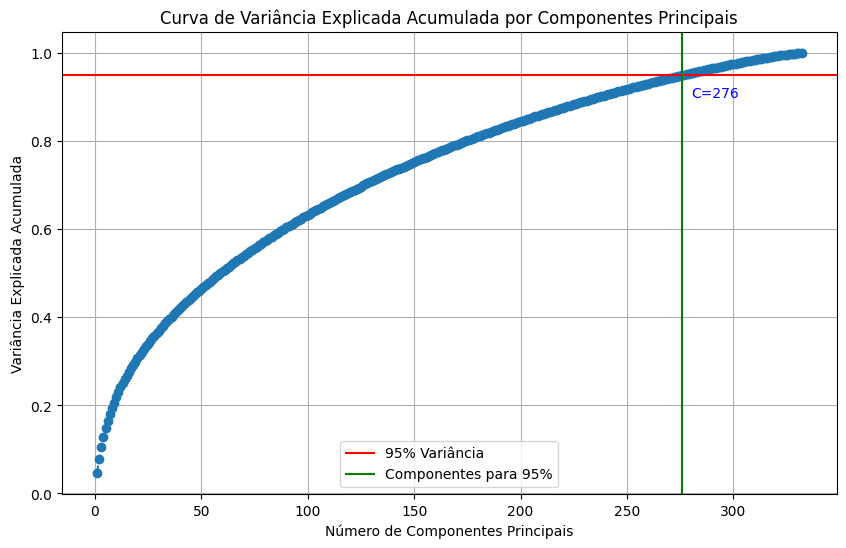

In [58]:
cumulative_variance_ratio = np.cumsum(X_pca1.explained_variance_ratio_)

plt.figure(figsize=(10, 6))

plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variância')
plt.axvline(x=np.argmax(cumulative_variance_ratio >= 0.95) + 1, color='g', linestyle='-', label='Componentes para 95%')

plt.annotate(
    f'C={np.argmax(cumulative_variance_ratio >= 0.95) + 1}',
    xy=(np.argmax(cumulative_variance_ratio >= 0.95) + 1, 0.95),
    xytext=(np.argmax(cumulative_variance_ratio >= 0.95) + 5, 0.9),
    color='blue'
)

plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Curva de Variância Explicada Acumulada por Componentes Principais')
plt.grid(True)

plt.legend()
plt.show()

## 📏 Clusterização K-Médias
📍 Utilizaremos o algoritmo K-Médias para agrupar os dados do conjunto de treinamento. O número ótimo de clusters será determinado com base em métricas como o método do cotovelo e o índice de silhueta.

In [59]:
pca = PCA(n_components=150) # Pouco acima de 75% de variânica explicada (reduzi devido ao tempo de processamento)
X_train_pca = pca.fit_transform(X_train_tfidf.toarray())

In [60]:
k_values = range(2, 100)

inertia = []
silhouette_scores = []

for k in k_values:
  kmeans = KMeans(
      n_clusters=k,
      random_state=42,
  )

  labels = kmeans.fit_predict(X_train_pca)
  inertia.append(kmeans.inertia_)
  silhouette_scores.append(
      silhouette_score(X_train_pca, labels)
  )

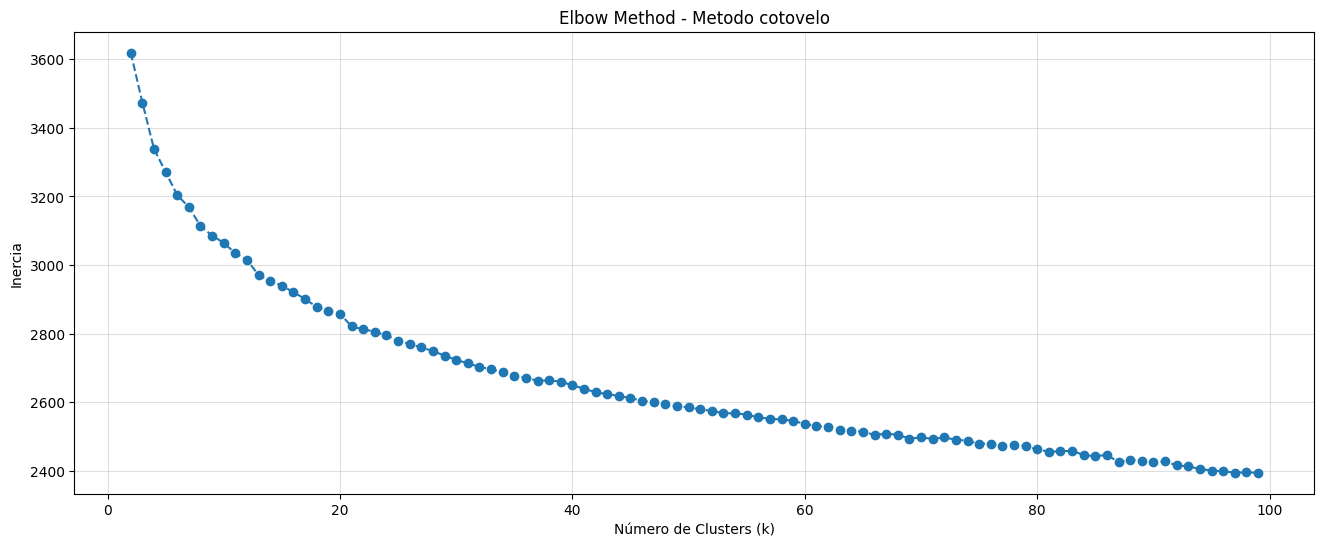

In [61]:
# Gráfico de cotovelo - Inércia
plt.figure(figsize=(16, 6))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Elbow Method - Metodo cotovelo')
plt.grid(alpha=0.4)
plt.show()

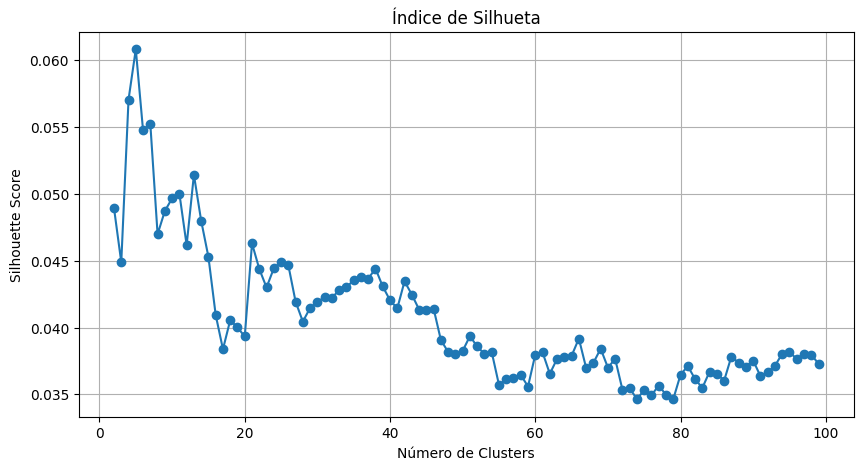

In [62]:
# Gráfico de Silhueta
plt.figure(figsize=(10,5))

plt.plot(k_values, silhouette_scores, marker='o')

plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')
plt.title('Índice de Silhueta')

plt.grid(True)
plt.show()

🗣️ Baseado nos dois plots acima, método de cotovelo e silhuete score, podemos ver que o número de clusters indicado fica próximo de 20. Olhando para o gráfico de silhuette score, com 21 clusters temos um pico no valor do score.

Agora vamos visualizar o score com 21 clusters.

In [63]:
kmeans = KMeans(
      n_clusters=21,
      random_state=42,
  )
kmeans.fit(X_train_pca)

KMeans(n_clusters=21, random_state=42)

Silhouette médio: 0.04629395087098182


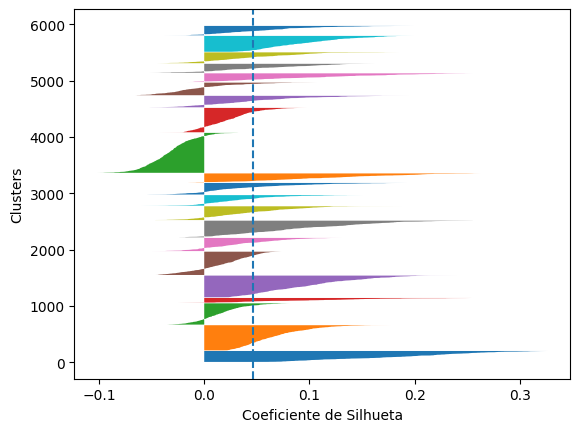

In [64]:
silhouette_avg = silhouette_score(X_train_pca, kmeans.labels_)
print("Silhouette médio:", silhouette_avg)

sample_silhouette_values = silhouette_samples(X_train_pca, kmeans.labels_)

y_lower = 10
for i in range(kmeans.n_clusters):
  values = sample_silhouette_values[kmeans.labels_ == i]
  values.sort()

  size_cluster = values.shape[0]
  y_upper = y_lower + size_cluster

  plt.fill_betweenx(np.arange(y_lower, y_upper), 0, values)

  y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, linestyle="--")
plt.xlabel("Coeficiente de Silhueta")
plt.ylabel("Clusters")
plt.show()

## 🤖 Criação de Features
📍 Para cada instância nos conjuntos de treinamento e teste, será gerada uma nova feature indicando a distância da instância ao centro do cluster mais próximo. Este processo visa incorporar a estrutura de agrupamento dos dados como uma informação adicional para o modelo de aprendizado supervisionado.

In [65]:
X_test_tfidf = tfidf.transform(X_test)
X_test_pca = pca.transform(X_test_tfidf.toarray())

In [66]:
train_distances = kmeans.transform(X_train_pca)
train_min_dist = train_distances.min(axis=1)
X_train_pca = pd.DataFrame(X_train_pca, columns=range(1, X_train_pca.shape[1] + 1))
X_train_pca['cluster_distance'] = train_min_dist


test_distances = kmeans.transform(X_test_pca)
test_min_dist = test_distances.min(axis=1)
X_test_pca = pd.DataFrame(X_test_pca, columns=range(1, X_test_pca.shape[1] + 1))
X_test_pca['cluster_distance'] = test_min_dist

## ⏳ Modelo de ML
📍 Serão treinados utilizando tanto o conjunto de features original quanto o conjunto de features expandido com as distâncias dos clusters. Use:
* Modelos SVM com diferentes configurações de kernel (linear, polinomial, RBF) e parâmetros de regularização para otimizar o desempenho.
* Modelos Random Forest com diferentes parâmetros para otimizar o desempenho.

In [67]:
# Support Vector Machine
svm = SVC(random_state=42, probability=True)

# Random Forest
rf = RandomForestClassifier(random_state=42)

# Scaler
scaler = StandardScaler()

# SVM Classifier
svm_classifier = Pipeline([
  ('scaler', scaler),
  ('svm', svm)
])

# Parâmetros para SVM
param_grid_svm = {
  'svm__kernel': ['linear','rbf','poly'],
  'svm__C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
}

# RF Classifier
rf_classifier = Pipeline([
  ('scaler', scaler),
  ('rf', rf)
])

# Parâmetros para RF
param_grid_rf = {
    'rf__n_estimators': [100, 200, 500],
    'rf__max_depth': [5, 8, 10]
}

In [68]:
# Embaralhamento dos dados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [69]:
X_train_pca.columns = X_train_pca.columns.astype(str)
X_test_pca.columns = X_test_pca.columns.astype(str)

In [70]:
# Amostragem das primeiras 1000 linhas (se rodar com toda a base, leva 1h em cada GridSearch)
X_train_pca = X_train_pca.iloc[0:1000,:]
y_train = y_train.iloc[0:1000]
X_test_pca = X_test_pca.iloc[0:1000,:]
y_test = y_test.iloc[0:1000]

In [71]:
# GridSearch para SVM
model_svm = GridSearchCV(
  estimator=svm_classifier,
  param_grid=param_grid_svm,
  scoring='accuracy',
  cv=cv,
  refit='precision',
  return_train_score=True,
  n_jobs=-1
).fit(X_train_pca, y_train)

In [72]:
# GridSearch para RF
model_rf = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid_rf,
    scoring='accuracy',
    cv=cv,
    refit='precision',
    return_train_score=True,
    n_jobs=-1
).fit(X_train_pca, y_train)

## ☑️ Avaliação de Modelos
📍 O desempenho dos modelos será avaliado com base em métricas de classificação padrão, como precisão, recall, F1-score e AUC-ROC, utilizando os conjuntos de teste.

In [73]:
best_svm = model_svm.best_estimator_
svm_pred = best_svm.predict(X_test_pca)
svm_proba = best_svm.predict_proba(X_test_pca)[:,1]

print(classification_report(y_test, svm_pred))

svm_auc = roc_auc_score(y_test, svm_proba)

print(f'AUC-ROC SVM: {svm_auc:.4f}')

              precision    recall  f1-score   support

           0       0.95      0.92      0.94       521
           1       0.92      0.95      0.93       479

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000

AUC-ROC SVM: 0.9827


In [74]:
best_rf = model_rf.best_estimator_
rf_pred = best_rf.predict(X_test_pca)
rf_proba = best_rf.predict_proba(X_test_pca)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)

print(f'AUC-ROC RF: {rf_auc:.4f}')


AUC-ROC RF: 0.9503


## 📈 Análise Comparativa
📍 Será realizada uma análise comparativa para avaliar o impacto da adição das features de clusterização no desempenho dos modelos de ML. Além disso, será discutida a influência do número de clusters e das configurações do ML nas métricas de desempenho. Use gráficos para ilustrar seus argumentos.

In [75]:
X_train_pca2 = pca.transform(X_train_tfidf.toarray())
X_test_pca2 = pca.transform(X_test_tfidf.toarray())

In [76]:
# Amostragem das primeiras 1000 linhas (se rodar com toda a base, leva 1h em cada GridSearch)
X_train_pca2 = pd.DataFrame(X_train_pca2).iloc[0:1000,:]
y_train = y_train.iloc[0:1000]
X_test_pca2 = pd.DataFrame(X_test_pca2).iloc[0:1000,:]
y_test = y_test.iloc[0:1000]

In [77]:
# GridSearch para SVM
model_svm2 = GridSearchCV(
  estimator=svm_classifier,
  param_grid=param_grid_svm,
  scoring='accuracy',
  cv=cv,
  refit='precision',
  return_train_score=True,
  n_jobs=-1
).fit(X_train_pca2, y_train)

# GridSearch para RF
model_rf2 = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid_rf,
    scoring='accuracy',
    cv=cv,
    refit='precision',
    return_train_score=True,
    n_jobs=-1
).fit(X_train_pca2, y_train)

In [78]:
best_svm2 = model_svm2.best_estimator_
svm_proba2 = best_svm2.predict_proba(X_test_pca2)[:,1]
svm_auc2 = roc_auc_score(y_test, svm_proba2)

In [79]:
best_rf2 = model_rf2.best_estimator_
rf_proba2 = best_rf2.predict_proba(X_test_pca2)[:, 1]
rf_auc2 = roc_auc_score(y_test, rf_proba2)

In [80]:
svm_fpr, svm_tpr, _ = roc_curve(
    y_test,
    svm_proba
)

svm_fpr2, svm_tpr2, _ = roc_curve(
    y_test,
    svm_proba2
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_proba
)

rf_fpr2, rf_tpr2, _ = roc_curve(
    y_test,
    rf_proba2
)

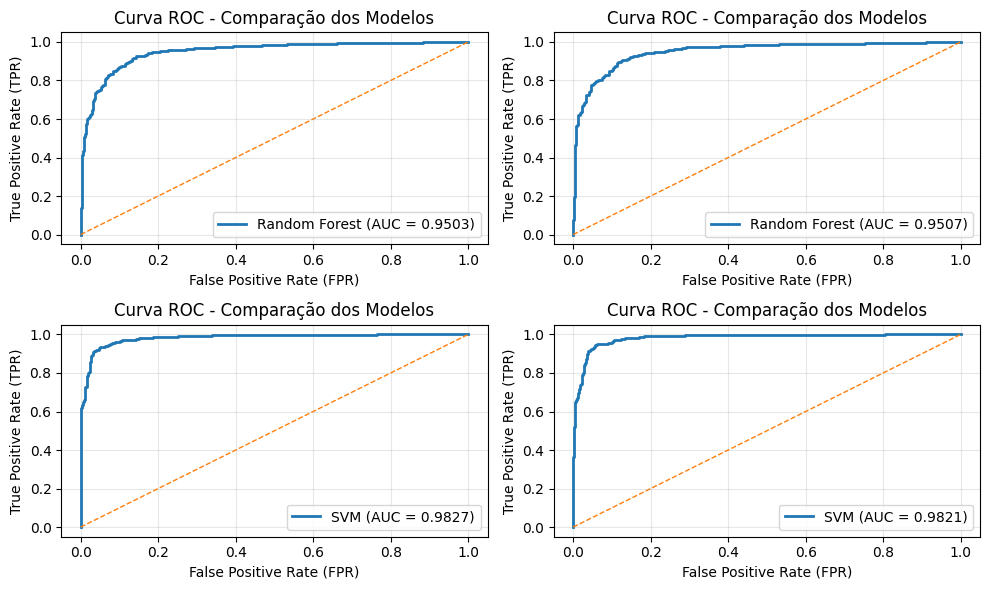

In [81]:
plt.figure(figsize=(10, 6))

# Random Forest
plt.subplot(2, 2, 1)
plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f'Random Forest (AUC = {rf_auc:.4f})'
)
# Linha aleatória
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1
)

# Configurações
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Comparação dos Modelos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)


plt.subplot(2, 2, 2)
plt.plot(
    rf_fpr2,
    rf_tpr2,
    linewidth=2,
    label=f'Random Forest (AUC = {rf_auc2:.4f})'
)
# Linha aleatória
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1
)

# Configurações
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Comparação dos Modelos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)


# SVM
plt.subplot(2, 2, 3)
plt.plot(
    svm_fpr,
    svm_tpr,
    linewidth=2,
    label=f'SVM (AUC = {svm_auc:.4f})'
)
# Linha aleatória
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1
)

# Configurações
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Comparação dos Modelos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)


plt.subplot(2, 2, 4)
plt.plot(
    svm_fpr2,
    svm_tpr2,
    linewidth=2,
    label=f'SVM (AUC = {svm_auc2:.4f})'
)
# Linha aleatória
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1
)

# Configurações
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Comparação dos Modelos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

🗣️ A adição da feature de distância ao cluster mais próximo teve impacto limitado no desempenho dos modelos supervisionados. Tanto o Random Forest quanto o SVM já apresentavam elevada capacidade discriminativa utilizando apenas as componentes principais obtidas pelo PCA. Apesar disso, a feature de clusterização adicionou informação estrutural aos dados, mantendo desempenho semelhante e demonstrando consistência na representação dos agrupamentos.